In [11]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

In [12]:
# Load dataset from project root/data
csv_path = Path.cwd().parent / "data" / "processed_train.csv"
if not csv_path.exists():
    csv_path = Path(r"D:/Traffic_Risk_Project/data/processed_train.csv")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded: d:\Traffic_Risk_Project\data\processed_train.csv
Shape: (23386, 4)


,video_id,start,end,caption
0,06d501fd-a9ffc960,0.0,11.0,The car accelerates because the light has turn...
1,06d501fd-a9ffc960,12.0,19.0,The car is moving at a steady speed because tr...
2,06d501fd-a9ffc960,20.0,22.0,The car slows slightly because it's turning in...
3,06d501fd-a9ffc960,23.0,36.0,The car stops because it turns to the right.
4,06d501fd-a9ffc960,37.0,40.0,The car accelerates because traffic is clear.


In [13]:
# Basic schema overview
print("Columns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())

Columns: ['video_id', 'start', 'end', 'caption']

Dtypes:
 video_id     object
start       float64
end         float64
caption      object
dtype: object

Missing values:
 video_id    0
start       0
end         0
caption     0
dtype: int64


## 1) Tổng quan dữ liệu

Phần này mô tả số lượng mẫu, số lượng video và thống kê cơ bản của các cột thời gian.

In [14]:
n_samples = len(df)
n_videos = df["video_id"].nunique() if "video_id" in df.columns else np.nan

print(f"Số mẫu: {n_samples:,}")
print(f"Số video_id duy nhất: {n_videos:,}")

if {"start", "end"}.issubset(df.columns):
    df["duration"] = df["end"] - df["start"]
    print("\nThống kê duration:")
    print(df["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
else:
    print("Không có cột start/end để tính duration")

Số mẫu: 23,386
Số video_id duy nhất: 5,997

Thống kê duration:
count    23386.000000
mean         8.746558
std         22.510797
min          0.000000
25%          3.000000
50%          6.000000
75%         12.000000
90%         19.000000
95%         21.000000
max       3208.000000
Name: duration, dtype: float64


In [16]:
df[df['duration'] > 40]

,video_id,start,end,caption,duration
1393,03c8da12-b57178f9,0.0,222.0,The car is driving forward because traffic is ...,222.0
3121,013aba02-3fbd03ff,22.0,3230.0,The slows down abruptly. The cars in front hav...,3208.0
3530,06924f46-1708b96f,32.0,367.0,The car slows to a stop because there's a stop...,335.0
5179,09ac7416-34ea8581,0.0,43.0,The car is stopped because the car is parked o...,43.0
5186,09ac7416-5a77d689,0.0,45.0,The car is stopped because the car is parked o...,45.0
5208,09ac7416-74752083,0.0,54.0,The car is stopped because he is parked on the...,54.0
5277,09ac7416-f97c710b,13.0,57.0,The car is driving forward because the light t...,44.0
9036,11035230-3b3d1ded,0.0,47.0,The car is stopped in traffic as the cars ahea...,47.0
9487,11a93b51-1af6063f,0.0,107.0,The car is parked and the hood is up because i...,107.0
11618,15e7be3e-64699f10,28.0,334.0,The car executes a u-turn from the parking spo...,306.0


In [ ]:
# cắt những video quá dài 
df = df[df['duration'] <= 100]

In [20]:
n_samples = len(df)
n_videos = df["video_id"].nunique() if "video_id" in df.columns else np.nan

print(f"Số mẫu: {n_samples:,}")
print(f"Số video_id duy nhất: {n_videos:,}")

if {"start", "end"}.issubset(df.columns):
    df["duration"] = df["end"] - df["start"]
    print("\nThống kê duration:")
    print(df["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
else:
    print("Không có cột start/end để tính duration")

Số mẫu: 23,381
Số video_id duy nhất: 5,996

Thống kê duration:
count    23381.000000
mean         8.569736
std          7.638472
min          0.000000
25%          3.000000
50%          6.000000
75%         12.000000
90%         19.000000
95%         21.000000
max         54.000000
Name: duration, dtype: float64


## 2) Chất lượng caption: độ dài và từ vựng thường gặp

Phần này đánh giá độ dài câu và mức độ lặp lại từ trong cột caption.

Thống kê độ dài caption (word count):
count    23386.000000
mean        13.808475
std          4.454292
min          2.000000
25%         11.000000
50%         13.000000
75%         16.000000
90%         19.000000
95%         22.000000
max         60.000000
Name: caption_len_words, dtype: float64


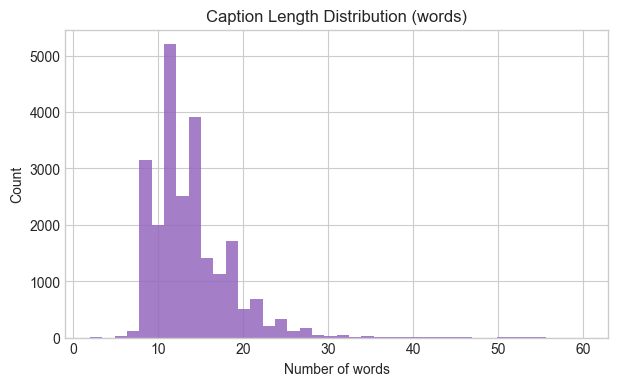


Top 25 từ xuất hiện nhiều nhất:


,count
caption,
the,48996
car,27073
is,25188
because,12700
a,9816
to,9595
it,6406
traffic,6333
down,5442


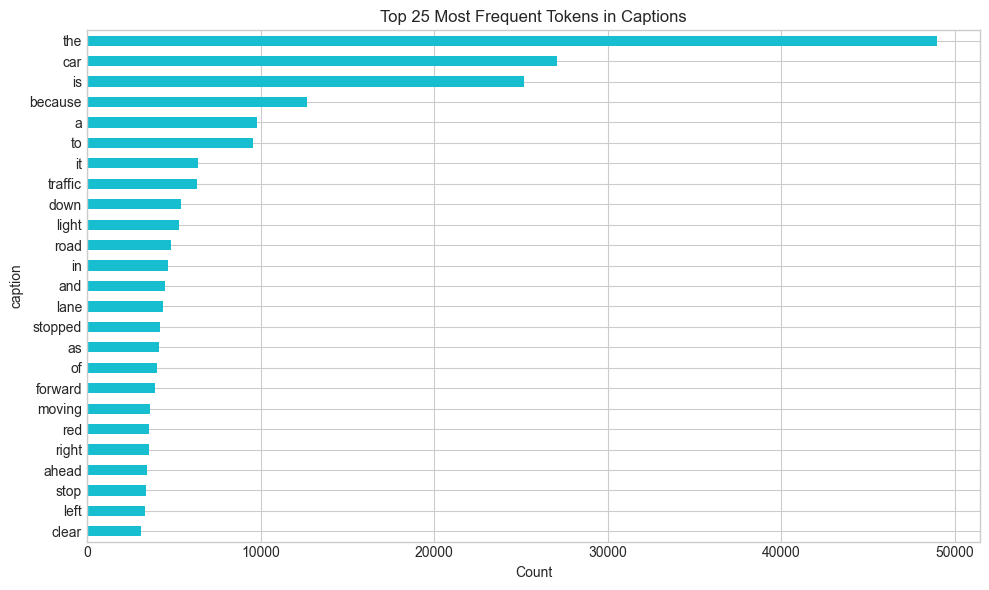

In [11]:
if "caption" in df.columns:
    cap = df["caption"].fillna("").astype(str)
    df["caption_len_words"] = cap.apply(lambda s: len(s.split()))

    print("Thống kê độ dài caption (word count):")
    print(df["caption_len_words"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

    plt.figure(figsize=(7, 4))
    plt.hist(df["caption_len_words"], bins=40, color="#9467bd", alpha=0.85)
    plt.title("Caption Length Distribution (words)")
    plt.xlabel("Number of words")
    plt.ylabel("Count")
    plt.show()

    # Simple token frequency
    token_series = cap.str.lower().str.replace(r"[^a-z0-9\s]", " ", regex=True).str.split().explode()
    token_freq = token_series[token_series.notna()].value_counts().head(25)

    print("\nTop 25 từ xuất hiện nhiều nhất:")
    display(token_freq.to_frame("count"))

    plt.figure(figsize=(10, 6))
    token_freq.sort_values().plot(kind="barh", color="#17becf")
    plt.title("Top 25 Most Frequent Tokens in Captions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Không có cột caption")

## 3) Mô phỏng chia tập Train/Val/Test

Xác nhận phân phối số lượng sau khi chia 80/10/10 như trong huấn luyện.

In [13]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

split_stats = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n_samples": [len(train_df), len(val_df), len(test_df)],
})
split_stats["ratio"] = split_stats["n_samples"] / len(df)

display(split_stats)
print("Total check:", split_stats["n_samples"].sum(), "==", len(df))

,split,n_samples,ratio
0,train,18708,0.799966
1,val,2339,0.100017
2,test,2339,0.100017


Total check: 23386 == 23386


## 4) Kết luận EDA và khuyến nghị tiền xử lý

Cell này tổng hợp các phát hiện chính và gợi ý bước làm sạch dữ liệu trước khi train.

In [15]:
summary = {}
summary["n_samples"] = len(df)
summary["n_video_id"] = df["video_id"].nunique() if "video_id" in df.columns else np.nan
summary["duration_negative_ratio"] = float((df["duration"] < 0).mean()) if "duration" in df.columns else np.nan
summary["duration_gt_60_ratio"] = float((df["duration"] > 60).mean()) if "duration" in df.columns else np.nan
summary["caption_len_p95"] = float(df["caption_len_words"].quantile(0.95)) if "caption_len_words" in df.columns else np.nan

summary_df = pd.DataFrame([summary])
display(summary_df)

print("Khuyến nghị:")
print("1) Loại hoặc sửa mẫu duration âm trước khi train.")
print("2) Cân nhắc cắt ngưỡng duration quá dài (outlier), ví dụ >60s.")
print("3) Chuẩn hóa pipeline ảnh/telemetry để tăng tỷ lệ dữ liệu đồng bộ.")
print("4) Duy trì max_length caption phù hợp vì p95 hiện tại khoảng", round(summary["caption_len_p95"], 2))

,n_samples,n_video_id,duration_negative_ratio,duration_gt_60_ratio,caption_len_p95
0,23386,5997,0.000257,0.000214,22.0


Khuyến nghị:
1) Loại hoặc sửa mẫu duration âm trước khi train.
2) Cân nhắc cắt ngưỡng duration quá dài (outlier), ví dụ >60s.
3) Chuẩn hóa pipeline ảnh/telemetry để tăng tỷ lệ dữ liệu đồng bộ.
4) Duy trì max_length caption phù hợp vì p95 hiện tại khoảng 22.0


## 5) Word Cloud cho Caption

Word Cloud giúp nhìn nhanh các từ khóa xuất hiện nhiều trong mô tả hành vi giao thông.

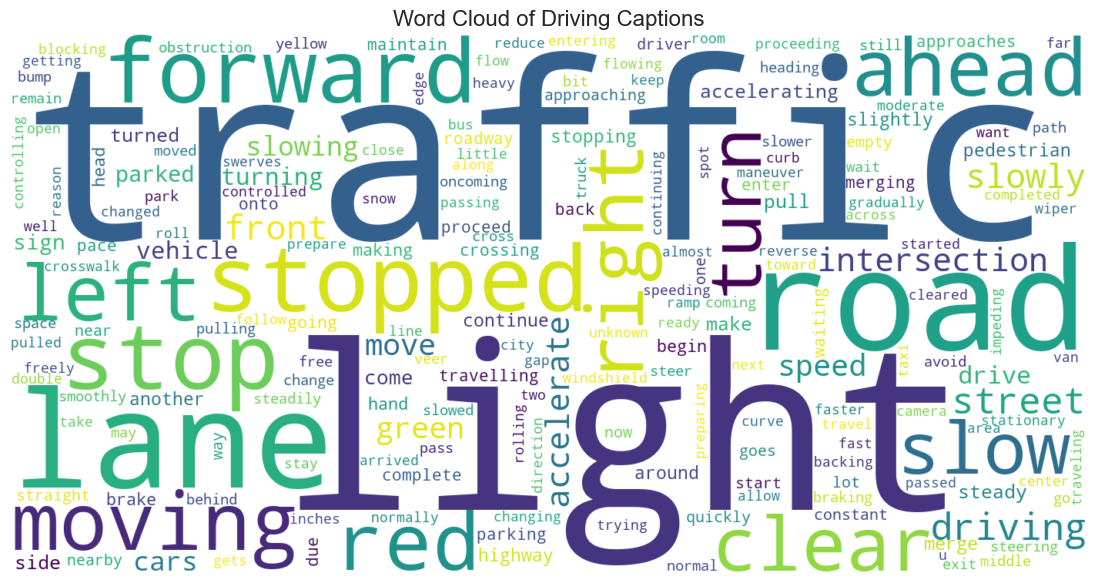

In [16]:
# Word Cloud for caption text
try:
    from wordcloud import WordCloud, STOPWORDS
except ImportError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    from wordcloud import WordCloud, STOPWORDS

text_data = " ".join(df["caption"].fillna("").astype(str).tolist()).lower()

custom_stopwords = set(STOPWORDS)
custom_stopwords.update({"car", "the", "is"})

wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=200,
    stopwords=custom_stopwords,
    colormap="viridis",
    collocations=False,
).generate(text_data)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Driving Captions", fontsize=16)
plt.show()

## 6) Word Cloud theo nhóm tình huống

So sánh từ khóa giữa các nhóm caption: `stop`, `left`, `right`, `traffic` để thấy khác biệt ngữ nghĩa.

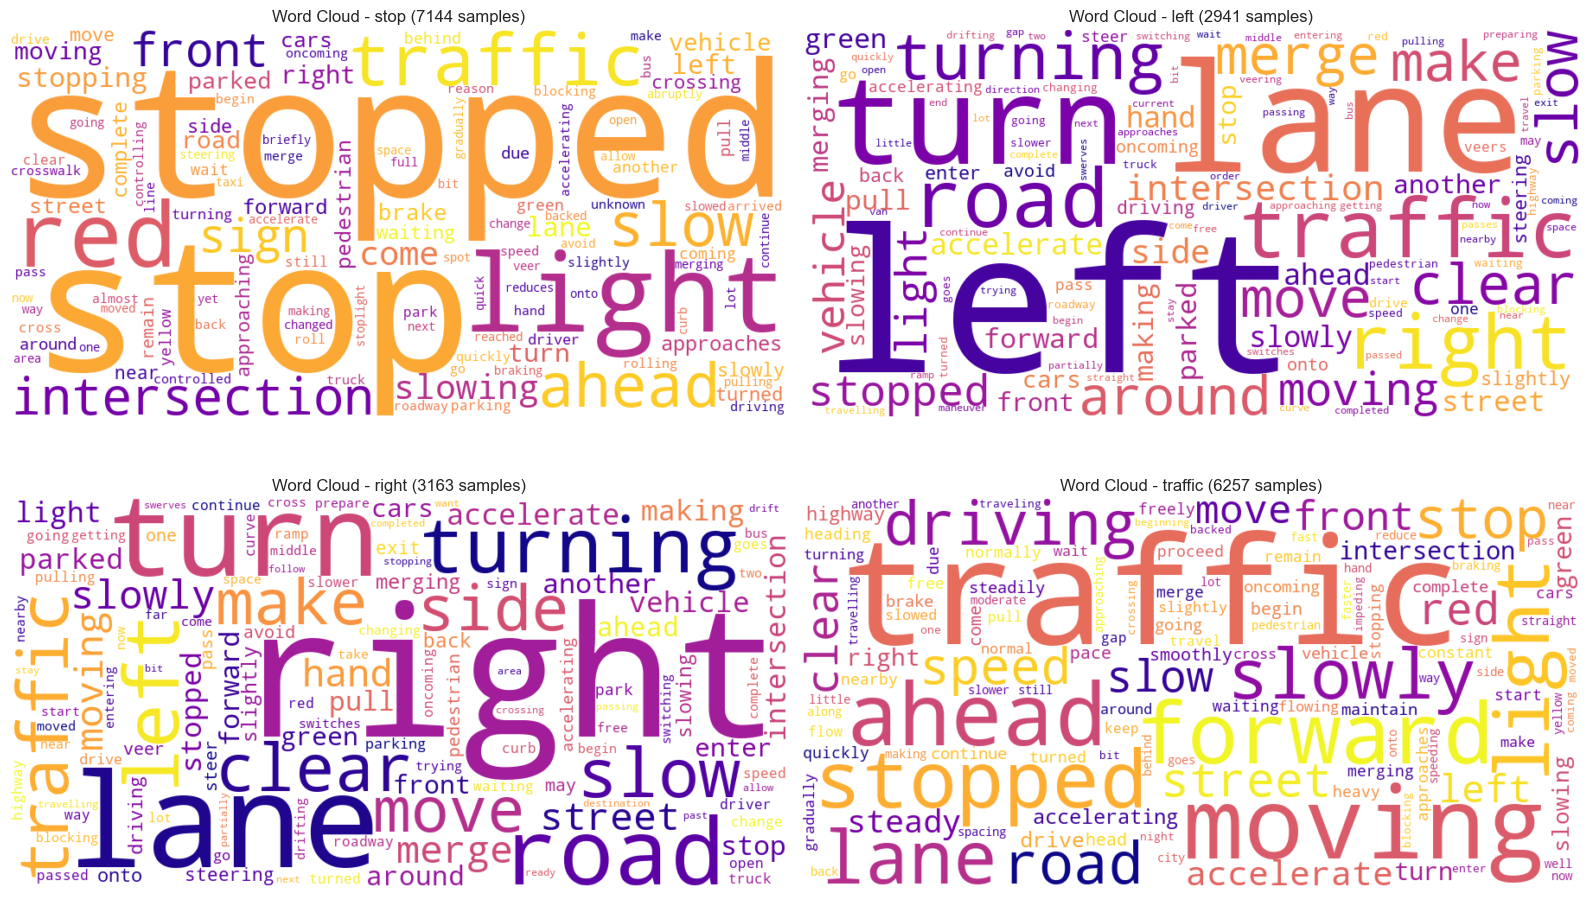

In [17]:
# Category-wise Word Clouds
caption_series = df["caption"].fillna("").astype(str).str.lower()

groups = {
    "stop": caption_series.str.contains(r"\bstop|stopped|stopping\b", regex=True),
    "left": caption_series.str.contains(r"\bleft\b", regex=True),
    "right": caption_series.str.contains(r"\bright\b", regex=True),
    "traffic": caption_series.str.contains(r"\btraffic\b", regex=True),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, (name, mask) in zip(axes, groups.items()):
    text_subset = " ".join(caption_series[mask].tolist())
    if len(text_subset.strip()) == 0:
        ax.text(0.5, 0.5, f"No data for {name}", ha="center", va="center", fontsize=12)
        ax.axis("off")
        continue

    wc_group = WordCloud(
        width=900,
        height=450,
        background_color="white",
        max_words=120,
        stopwords=custom_stopwords,
        colormap="plasma",
        collocations=False,
    ).generate(text_subset)

    ax.imshow(wc_group, interpolation="bilinear")
    ax.set_title(f"Word Cloud - {name} ({mask.sum()} samples)")
    ax.axis("off")

plt.tight_layout()
plt.show()